## TOPIC : Stack Overflow Developer Survey Analysis 2024

## Outcome : Can data predict what makes an Indian developer rich?

## Data Source : Stack Overflow 2024 | Kaggle
Total Responses: 65,437 | Indian Developers: 4,231

In [2]:
# Importing required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('Data/survey_results_public.csv')
print("Shape:", df.shape)


Shape: (65437, 114)


In [3]:
df.columns # Displays all column names in the dataset

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

In [4]:
df.head() # Displays the top rows of the DF

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [5]:
df.info() # Gives Statistical Summary

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


In [6]:
df.isnull().sum() #Finds the sum of Null Values

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [7]:
df.columns.tolist() #Gives all columns name

['ResponseId',
 'MainBranch',
 'Age',
 'Employment',
 'RemoteWork',
 'Check',
 'CodingActivities',
 'EdLevel',
 'LearnCode',
 'LearnCodeOnline',
 'TechDoc',
 'YearsCode',
 'YearsCodePro',
 'DevType',
 'OrgSize',
 'PurchaseInfluence',
 'BuyNewTool',
 'BuildvsBuy',
 'TechEndorse',
 'Country',
 'Currency',
 'CompTotal',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'LanguageAdmired',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'DatabaseAdmired',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'PlatformAdmired',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'WebframeAdmired',
 'EmbeddedHaveWorkedWith',
 'EmbeddedWantToWorkWith',
 'EmbeddedAdmired',
 'MiscTechHaveWorkedWith',
 'MiscTechWantToWorkWith',
 'MiscTechAdmired',
 'ToolsTechHaveWorkedWith',
 'ToolsTechWantToWorkWith',
 'ToolsTechAdmired',
 'NEWCollabToolsHaveWorkedWith',
 'NEWCollabToolsWantToWorkWith',
 'NEWCollabToolsAdmired',
 'OpSysPersonal use',
 'OpSysProfessional use',
 'OfficeStackAsyncHa

In [8]:
# Filter only Indian developers from global dataset
df_india = df[df['Country'] == 'India']
print("India respondents:", len(df_india))

India respondents: 4231


In [9]:
df_india.isnull().sum()[df_india.isnull().sum() > 0]

RemoteWork             1094
CodingActivities       1092
LearnCode                21
LearnCodeOnline         838
TechDoc                1799
                       ... 
JobSatPoints_11        2191
SurveyLength            309
SurveyEase              314
ConvertedCompYearly    3194
JobSat                 2221
Length: 107, dtype: int64

Salary column(ConvertedCompYearly) is having 3,194 null values out of 4,231,
therefore droping it as it will make analysis biased.

In [10]:
# Drop rows where salary is missing to avoid biased analysis
df_india_salary = df_india.dropna(subset=['ConvertedCompYearly'])
print(df_india_salary.shape)

(1037, 114)


After removing missing salary values, we are left with 
1,037 Indian developers who disclosed their salary out of 4,231.

Converting salary from USD to INR for better understanding.
Exchange rate used: 1 USD = 94.78 INR (March 2026)

In [11]:
# Convert salary from USD to INR using current exchange rate
usd_to_inr = 94.78
df_india_salary['Salary_INR'] = df_india_salary['ConvertedCompYearly'] * usd_to_inr
df_india_salary[['ConvertedCompYearly', 'Salary_INR']].head()



,ConvertedCompYearly,Salary_INR
548,13160.0,1247304.80
613,5982.0,566973.96
665,47854.0,4535602.12
695,43068.0,4081985.04
722,9571.0,907139.38


### Checking Salary Range
 Finding the Maximum and Minimum salaries to detect any outliers

In [12]:
print("Max Salary:", df_india_salary['Salary_INR'].max())
print("Min Salary:", df_india_salary['Salary_INR'].min())

Max Salary: 319192122.48
Min Salary: 94.78


### Removing Outliers

Max salary was ₹31 crore and min was ₹95 per year, 
clearly unrealistic entries in the survey.

I use the IQR method to remove these extreme values 
and keep only realistic salaries for accurate analysis.

In [13]:
# Calculate IQR to identify and remove extreme salary outliers
Q1 = df_india_salary['Salary_INR'].quantile(0.25)
Q3 = df_india_salary['Salary_INR'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_india_salary = df_india_salary[
    (df_india_salary['Salary_INR'] >= lower) & 
    (df_india_salary['Salary_INR'] <= upper)
]

print("After removing outliers:", df_india_salary.shape)

After removing outliers: (993, 115)


Before outlier removal = 1,037 rows

After outlier removal  = 993 rows

Removed                = 44 extreme salary entries

In [14]:
df_india_salary['Employment'].value_counts()

Employment
Employed, full-time                                                                                                                                                      809
Independent contractor, freelancer, or self-employed                                                                                                                      59
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                                                  58
Employed, full-time;Student, part-time                                                                                                                                    12
Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time                                                                               8
Employed, part-time                                                                                                         

### Employed full-time = 809 out of 993
That is 81% of Indian developers with salary data are full-time employed

In [15]:
df_india_ft = df_india_salary[df_india_salary['Employment'] == 'Employed, full-time']
print(df_india_ft.shape)

(809, 115)


### Most Used Programming Languages by Indian Developers

Analyzing which programming languages are most commonly 
used by full-time employed Indian developers.

Since one developer can know multiple languages seprated by ";", 
we split and count each language individually

In [16]:
languages = df_india_ft['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
language_counts = languages.value_counts().head(10)
print(language_counts)

LanguageHaveWorkedWith
JavaScript                 540
HTML/CSS                   428
SQL                        411
Python                     359
TypeScript                 310
Java                       282
C++                        161
Bash/Shell (all shells)    144
C#                         139
PHP                        138
Name: count, dtype: int64


Surprisingly Javascript is #1 not Python.
Python is at #4 which is unexpected for a country known for IT and data science work.
This shows India's developer market is dominated by web development, not data science. Python is growing but JavaScript still rules.


### Which programming language earns the highest salary in India?

In [17]:
# Create empty dictionary to store language and salary
language_salary = {}

# Loop through each row
for _, row in df_india_ft.iterrows():
    # Skip if language or salary is empty
    if pd.isna(row['LanguageHaveWorkedWith']) or pd.isna(row['Salary_INR']):
        continue
    # Split languages by ";"
    langs = row['LanguageHaveWorkedWith'].split(';')
    # For each language add salary to dictionary
    for lang in langs:
        if lang not in language_salary:
            language_salary[lang] = []
        language_salary[lang].append(row['Salary_INR'])

print("Done. Total languages found:", len(language_salary))

Done. Total languages found: 47


In [18]:
# Count average salary per language
# Only include languages used by minimum 10 people
avg_salary_filtered = {lang: np.mean(salaries) 
                      for lang, salaries in language_salary.items() 
                      if len(salaries) >= 10}

# Convert to dataframe and sort highest to lowest
lang_salary_df = pd.DataFrame(
    list(avg_salary_filtered.items()), 
    columns=['Language', 'Avg_Salary_INR']
)
lang_salary_df = lang_salary_df.sort_values(
    'Avg_Salary_INR', ascending=False
).head(10)

# Convert to readable format in lakhs
lang_salary_df['Avg_Salary_Lakhs'] = (lang_salary_df['Avg_Salary_INR'] / 100000).round(2)
print(lang_salary_df[['Language', 'Avg_Salary_Lakhs']])

                   Language  Avg_Salary_Lakhs
24                   Groovy             31.52
20                     Perl             26.80
7                      Ruby             26.46
11                       Go             26.07
25                    Scala             25.54
8   Bash/Shell (all shells)             24.53
19                      Lua             24.42
27                 Assembly             23.75
15                    Swift             23.41
12                     Rust             23.28


Most Indian freshers learn Python and JavaScript. But the data shows niche languages like Groovy, Go, Scala and Rust pay significantly more. Learning one niche language alongside Python could give a major salary advantage.

### Visualizing average salary by programming language

Java, Python and JavaScript are most popular but their average salary is pulled down because both freshers and seniors use them. Niche languages like Groovy and Scala are mostly used by experienced senior developers which pushes their average salary higher.

Most popular languages used by Indian developers 
and their average salary

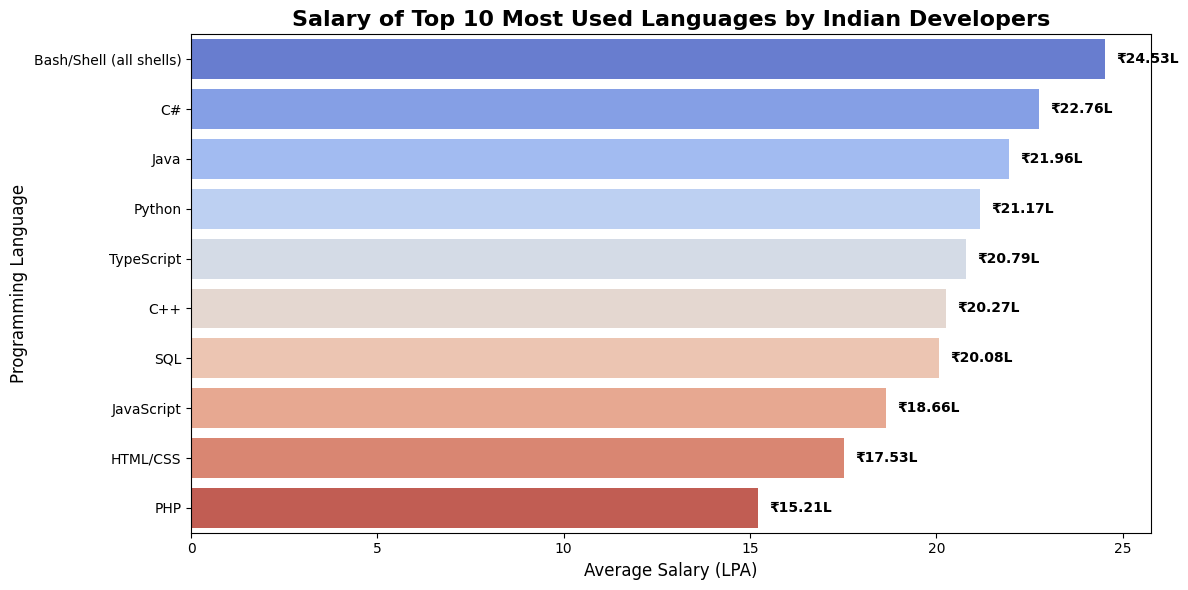

In [19]:
# Get top 10 most used languages
top_languages = language_counts.head(10).index.tolist()

# Filter salary data for only top 10 most used languages
popular_lang_salary = {lang: np.mean(language_salary[lang]) 
                      for lang in top_languages 
                      if lang in language_salary}

# Convert to lakhs
popular_lang_df = pd.DataFrame(
    list(popular_lang_salary.items()),
    columns=['Language', 'Avg_Salary_INR']
)
popular_lang_df['Avg_Salary_Lakhs'] = (popular_lang_df['Avg_Salary_INR'] / 100000).round(2)
popular_lang_df = popular_lang_df.sort_values('Avg_Salary_Lakhs', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=popular_lang_df,
    x='Avg_Salary_Lakhs',
    y='Language',
    hue='Language',
    palette='coolwarm',
    legend=False
)

# Add value labels
for i, v in enumerate(popular_lang_df['Avg_Salary_Lakhs']):
    ax.text(v + 0.3, i, f'₹{v}L', va='center', fontweight='bold')

plt.title('Salary of Top 10 Most Used Languages by Indian Developers',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (LPA)', fontsize=12)
plt.ylabel('Programming Language', fontsize=12)
plt.tight_layout()
plt.show()

Does work experience actually increase salary for Indian developers?

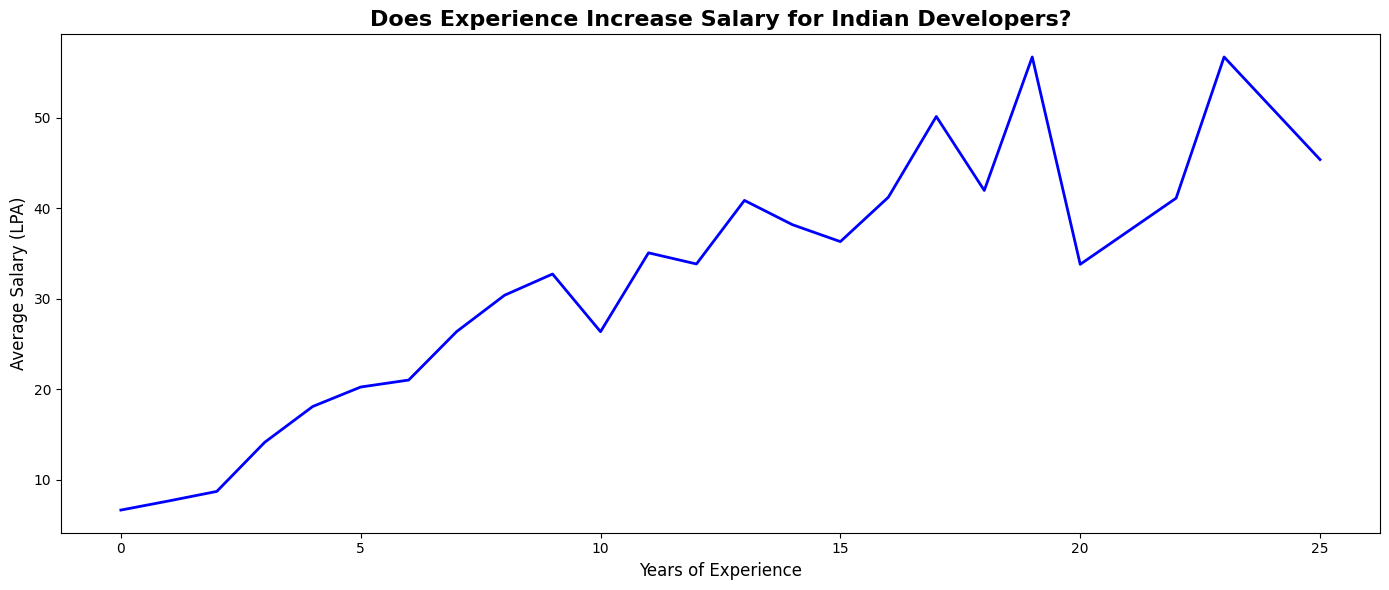

In [20]:
# Drop rows where experience is missing
exp_salary = df_india_ft[['WorkExp', 'Salary_INR']].dropna()

# Convert experience to numeric
exp_salary['WorkExp'] = pd.to_numeric(exp_salary['WorkExp'], errors='coerce')

# Drop any remaining nulls
exp_salary = exp_salary.dropna()

# Group by experience and calculate average salary
exp_grouped = exp_salary.groupby('WorkExp')['Salary_INR'].mean().reset_index()
exp_grouped['Avg_Salary_Lakhs'] = (exp_grouped['Salary_INR'] / 100000).round(2)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=exp_grouped,
    x='WorkExp',
    y='Avg_Salary_Lakhs',
    color='blue',
    linewidth=2
)

plt.title('Does Experience Increase Salary for Indian Developers?',
          fontsize=16, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Average Salary (LPA)', fontsize=12)
plt.tight_layout()
plt.show()

Experience clearly increases salary in India. Developers with 0 years earn around ₹7L while those with 20 years earn ₹57L. However the growth is not always smooth, some dips suggest skills matter more than just years of experience alone.

Does education degree matter for salary in Indian developers?

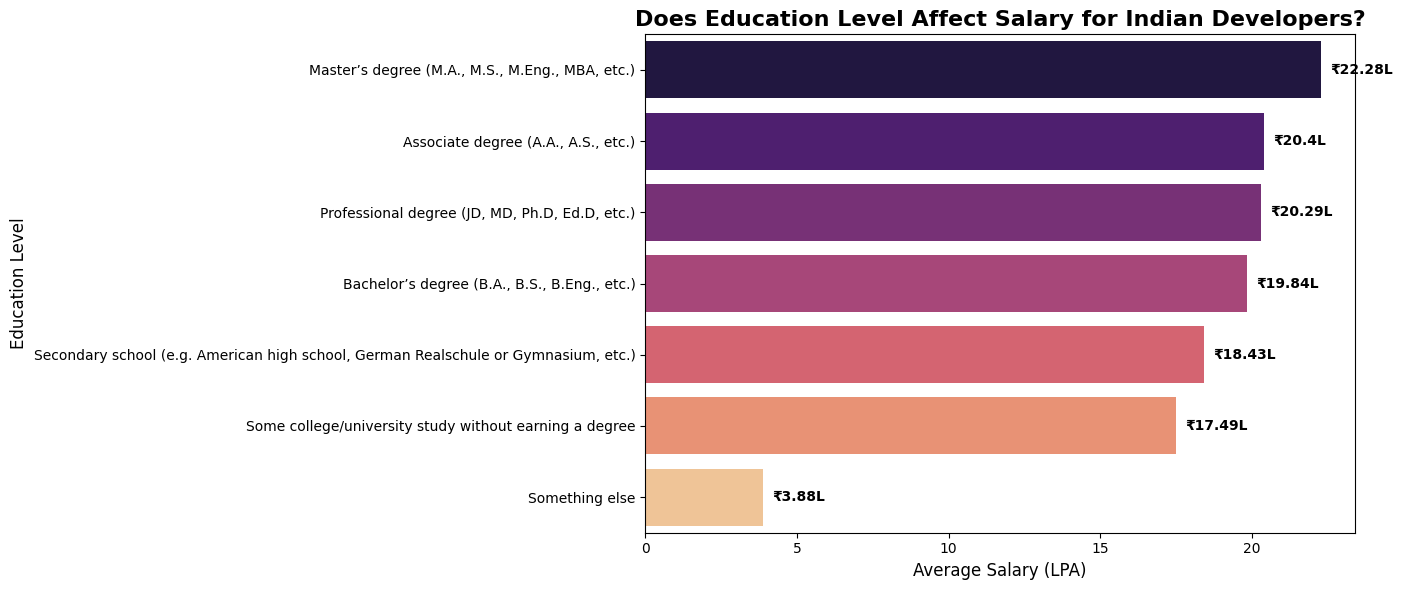

In [21]:
# Drop rows where education or salary is missing
edu_salary = df_india_ft[['EdLevel', 'Salary_INR']].dropna()

# Calculate average salary per education level
edu_grouped = edu_salary.groupby('EdLevel')['Salary_INR'].mean().reset_index()
edu_grouped['Avg_Salary_Lakhs'] = (edu_grouped['Salary_INR'] / 100000).round(2)
edu_grouped = edu_grouped.sort_values('Avg_Salary_Lakhs', ascending=False)

# Plot
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=edu_grouped,
    x='Avg_Salary_Lakhs',
    y='EdLevel',
    hue='EdLevel',
    palette='magma',
    legend=False
)

# Add value labels
for i, v in enumerate(edu_grouped['Avg_Salary_Lakhs']):
    ax.text(v + 0.3, i, f'₹{v}L', va='center', fontweight='bold')

plt.title('Does Education Level Affect Salary for Indian Developers?',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (LPA)', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.tight_layout()
plt.show()

Master's degree holders earn the most at ₹22.28L. But surprisingly developers without a degree still earn ₹17.49L. In India education helps but it is not the only path to a good salary, skills matter equally.

Does working remotely pay more than working from office in India?

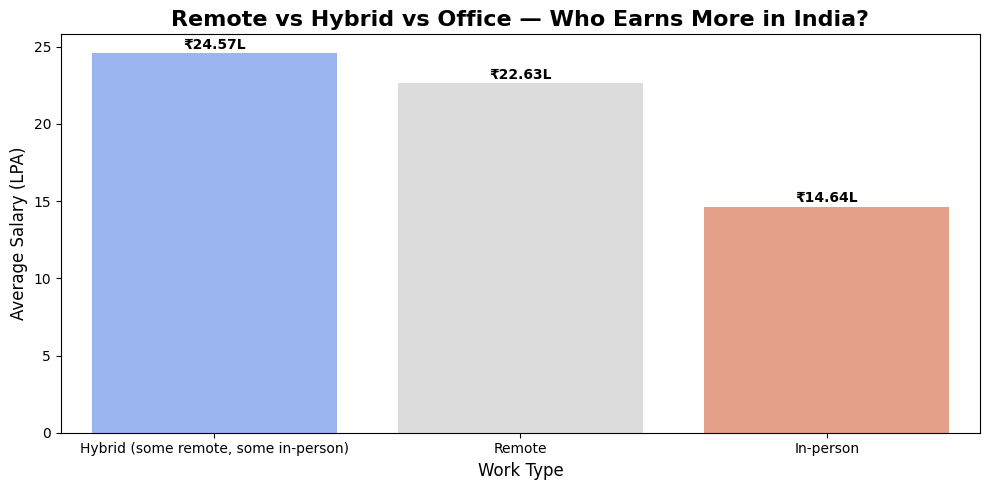

In [22]:
# Drop rows where remote work or salary is missing
remote_salary = df_india_ft[['RemoteWork', 'Salary_INR']].dropna()

# Calculate average salary per remote work type
remote_grouped = remote_salary.groupby('RemoteWork')['Salary_INR'].mean().reset_index()
remote_grouped['Avg_Salary_Lakhs'] = (remote_grouped['Salary_INR'] / 100000).round(2)
remote_grouped = remote_grouped.sort_values('Avg_Salary_Lakhs', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=remote_grouped,
    x='RemoteWork',
    y='Avg_Salary_Lakhs',
    hue='RemoteWork',
    palette='coolwarm',
    legend=False
)

# Add value labels on bars
for i, v in enumerate(remote_grouped['Avg_Salary_Lakhs']):
    ax.text(i, v + 0.3, f'₹{v}L', ha='center', fontweight='bold')

plt.title('Remote vs Hybrid vs Office — Who Earns More in India?',
          fontsize=16, fontweight='bold')
plt.xlabel('Work Type', fontsize=12)
plt.ylabel('Average Salary (LPA)', fontsize=12)
plt.tight_layout()
plt.show()

Hybrid workers earn the most at ₹24.57L, even more than fully remote workers at ₹22.63L. In-person office workers earn the least at ₹14.64L. This suggests that flexibility in work style is rewarded more than full remote work in India.

### Which developer type earns most in India?

In [24]:
# Drop rows where developer type or salary is missing
# Split developer types by ";" and explode into separate rows
dev_salary = df_india_ft[['DevType', 'Salary_INR']].dropna()
dev_salary = dev_salary.copy()
dev_salary['DevType'] = dev_salary['DevType'].str.split(';')
dev_salary = dev_salary.explode('DevType')

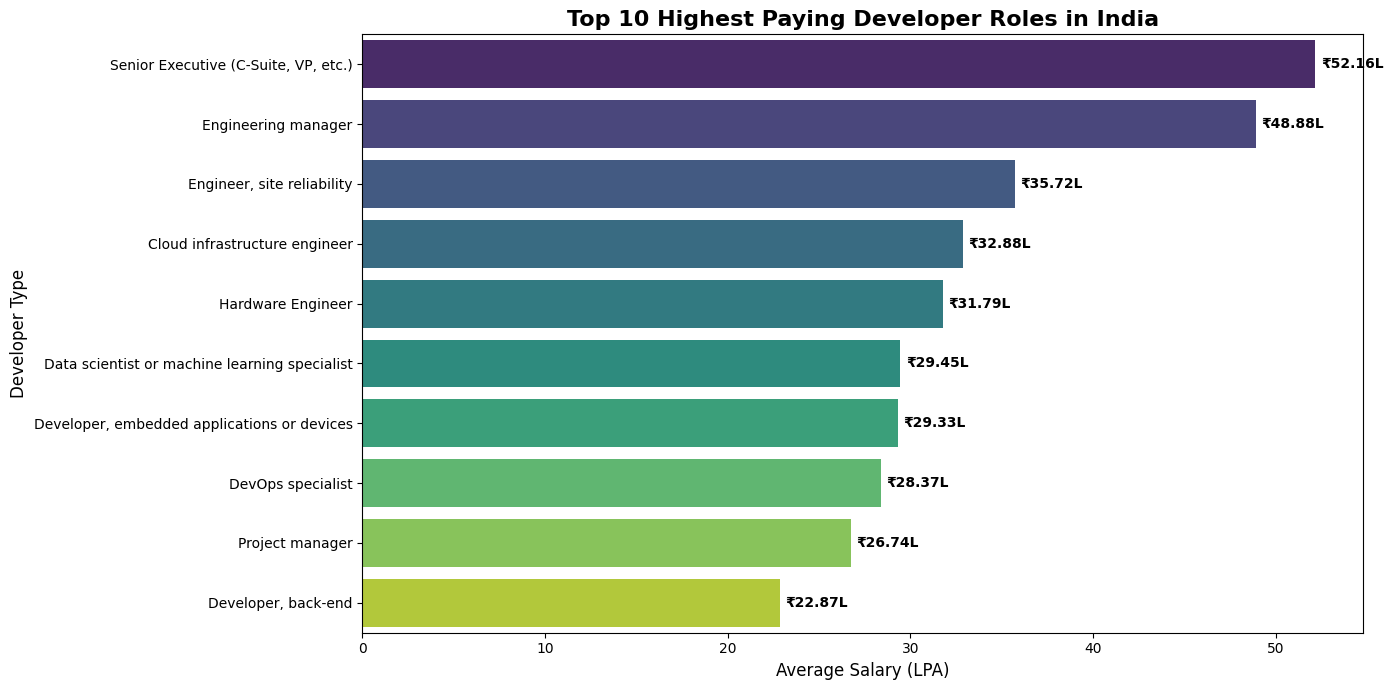

In [25]:
# Remove "Other" category and clean up labels
dev_salary_clean = dev_salary[dev_salary['DevType'] != 'Other (please specify):']

# Calculate average salary per developer type
dev_grouped = dev_salary_clean.groupby('DevType')['Salary_INR'].mean().reset_index()
dev_grouped['Avg_Salary_Lakhs'] = (dev_grouped['Salary_INR'] / 100000).round(2)
dev_grouped = dev_grouped.sort_values('Avg_Salary_Lakhs', ascending=False).head(10)

# Plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=dev_grouped,
    x='Avg_Salary_Lakhs',
    y='DevType',
    hue='DevType',
    palette='viridis',
    legend=False
)

# Add value labels
for i, v in enumerate(dev_grouped['Avg_Salary_Lakhs']):
    ax.text(v + 0.3, i, f'₹{v}L', va='center', fontweight='bold')

plt.title('Top 10 Highest Paying Developer Roles in India',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (LPA)', fontsize=12)
plt.ylabel('Developer Type', fontsize=12)
plt.tight_layout()
plt.show()

Data Scientist and ML roles rank 6th with ₹29.45L average salary. Leadership roles like Senior Executive and Engineering Manager dominate the top with ₹52L+ — suggesting that technical skills combined with leadership experience gives the highest returns in India.

### Business Recommendations
1) Learn Python + Bash/Shell as your core skills. Python is widely used and Bash pays ₹24.53L among popular languages.
2) Target hybrid or remote jobs. Hybrid workers earn ₹24.57L vs ₹14.64L for office workers nearly double.
3) Pursue a Master's degree if possible. It gives ₹22.28L vs ₹17.49L without degree ₹5L difference annually.
4) Aim for Data Scientist or Cloud Engineer role. Both pay ₹29L+ and are high growth fields in India.
5) Invest in experience. Salary grows from ₹7L at 0 years to ₹57L at 20 years skills compound over time.

### Key Takeaways
1. What surprised me the most?

   Java and Python are the most popular languages but not the 
   highest paying. Uncommon languages like Groovy and Scala 
   pay significantly more.
2. What would I tell a fresher?

   Give 100% in your chosen field. Depth of knowledge matters 
   more than popularity of the language. Specialists get paid more. 
3. What would I do differently?

   After strengthening Data Science skills, I will explore 
   niche languages like Go, Scala or Rust to maximize salary potential.  